In [1]:
import scipy.optimize as so
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import time_domain_DRT as drt

In [2]:
# Define plotting assistants 
# List of default colors
color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Plot parameters and sizes
plt.rc('font', size = 16)
plt.rc('axes', linewidth=1, titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)    # fontsize of the x and y labels
plt.rc('xtick', top=True, bottom=True, direction='in')
plt.rc('ytick', left=True, right=True, direction='in') 
plt.rc('figure', titlesize=5)
plt.rc('legend', fontsize=14)
plt.rc('lines', linewidth=2)

In [3]:
# Read in the simulation data
data = pd.read_csv("tj.dat", sep=r'\s+')

[]

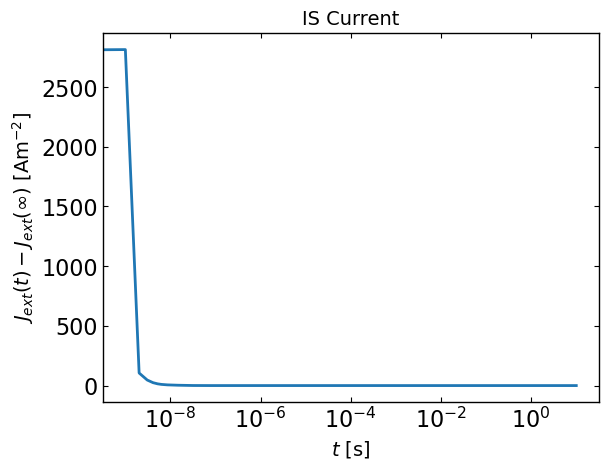

In [4]:
# Examine the exit current from the device against time
plt.plot(data['t'], data['Jext']-data['Jext'].iloc[-1])
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("IS Current")
plt.plot()

In [5]:
# Define the window of time and current I will look at
start_index = 64
end_index = -1 #849
time = data['t'].iloc[start_index:end_index].values
current = data['Jext'].iloc[start_index:end_index].values
current_error = data['errJ'].iloc[start_index:end_index].values
current_upper_lim = current + current_error
current_lower_lim = current - current_error

[]

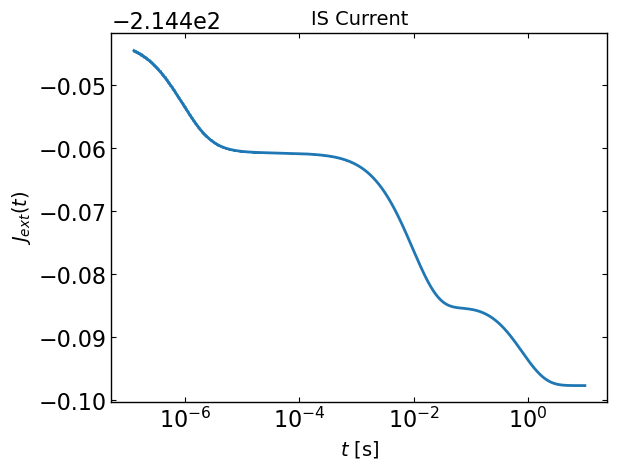

In [6]:
# Define impedance in realtime 
plt.errorbar(time, current, yerr=current_error)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$')
plt.title("IS Current")
plt.plot()


In [65]:
# Calculate the cost betwen the central curve and the curves +- error to get an experimental error threshold 
cost_threshold = 2*np.sqrt(np.square(current_error).sum())
current_cost = (1/2)*np.square(current_error)
print(f"Cost Threshold: {cost_threshold:.3}")

Cost Threshold: 0.00255


In [66]:
# Apply scaling to the current 
scaled_current = (current - current.min())/(current.max()-current.min())
scaled_cost_threshold = cost_threshold/(current.max()-current.min())**2
scaled_current_error = current_error/(current.max()-current.min())**2
scaled_current_cost = current_cost/(current.max()-current.min())**2

In [9]:
# Find the DRT fits for m=1,...,10
# Set the values for intial guesses that don't depend on m
polarity = 1 if time[-1] < time[0] else -1
offset0 = scaled_current.max() if polarity == 1 else scaled_current.min()

# Set iteration variables
m_values = range(1,11)
fits = []

for m in m_values:
    # Set the initial guesses for parameters that do depend on m
    U0 = np.ones(m)/m
    tau0 = np.geomspace(time[0], time[-1], m)

    # Apply the fit
    fit = drt.fit_DRT_curve(time, scaled_current, U0, tau0, offset0=offset0) 

    # Add to collection of fits
    fits.append(fit)

/home/josh-edmundson/Documents/Projects/Setting up Time-Domain Distribution of Relaxation Time (DRT) Fitting in Python/Default IMPLS Sim/time_domain_DRT.py:92: RuntimeWarning: overflow encountered in exp
  calculated_DRT_curve = (U @ np.exp(-np.outer(1/tau, t))) + offset
/home/josh-edmundson/miniconda3/envs/pySIMsalabim/lib/python3.13/site-packages/scipy/optimize/_lsq/trf.py:527: RuntimeWarning: overflow encountered in dot
  cost_new = 0.5 * np.dot(f_new, f_new)


[]

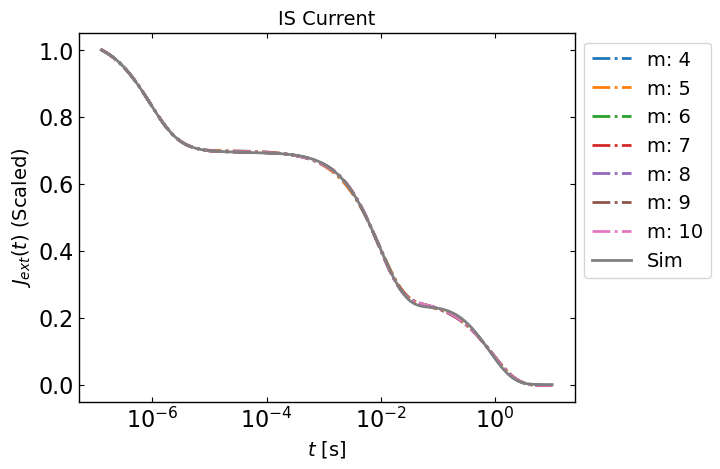

In [ ]:
# Plot all the fits to make sure they make physical sense
for fit in fits: 
    plt.plot(time, fit.DRT_curve, label=f"m: {fit.m}", linestyle="-.")

plt.plot(time, scaled_current, label='Sim')
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$ (Scaled)')
plt.title("IS Current")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.plot()

[]

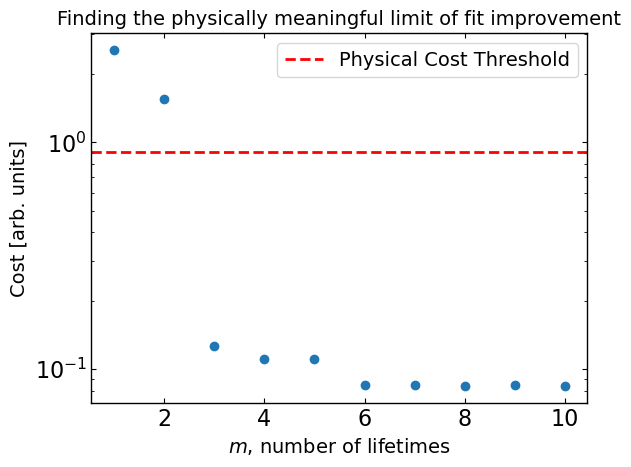

In [11]:
m_and_scaled_costs = np.array([[fit.m, np.sqrt(2*fit.cost)] for fit in fits])

plt.scatter(m_and_scaled_costs[:, 0], m_and_scaled_costs[:, 1])
plt.axhline(scaled_cost_threshold, linestyle='--', label='Physical Cost Threshold', color='red')
plt.xlabel('$m$, number of lifetimes')
plt.ylabel('Cost [arb. units]')
plt.yscale('log')
plt.title("Finding the physically meaningful limit of fit improvement")
plt.legend()
plt.plot()

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5928/3147634648.py:21: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(time, scaled_current_error, label='$\sigma_J$', color='grey', linestyle=':')


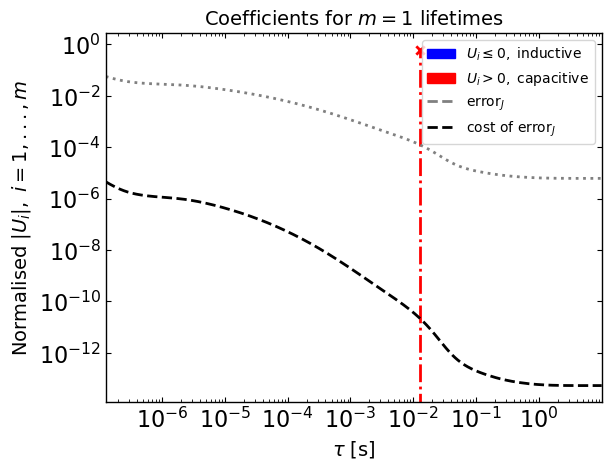

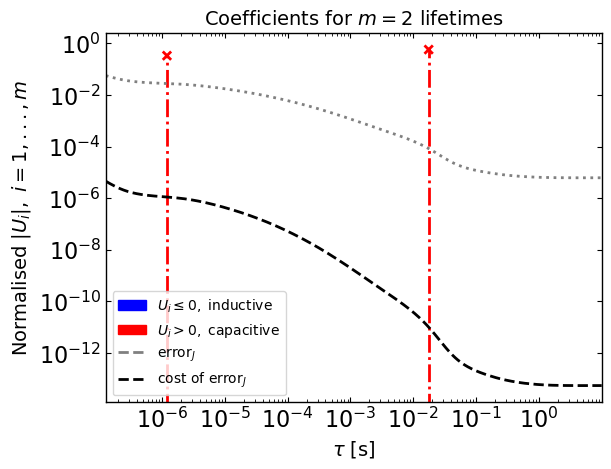

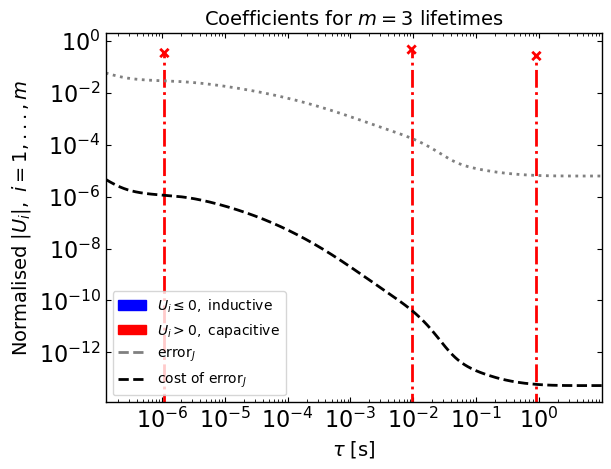

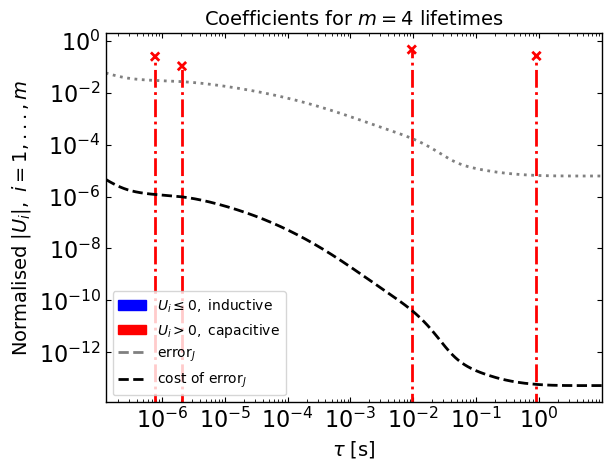

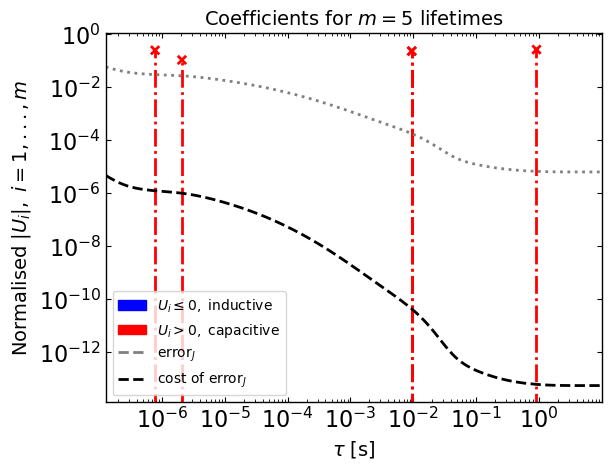

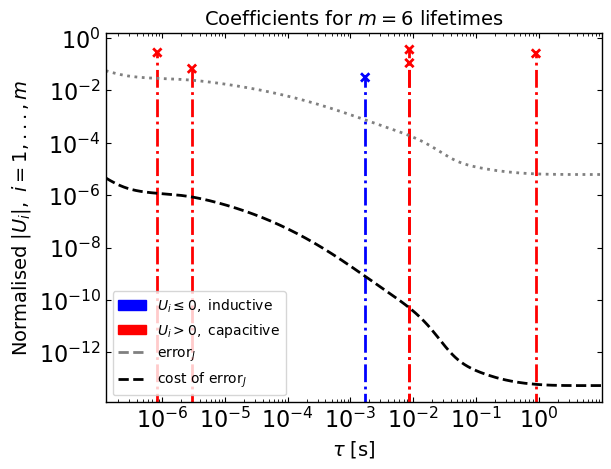

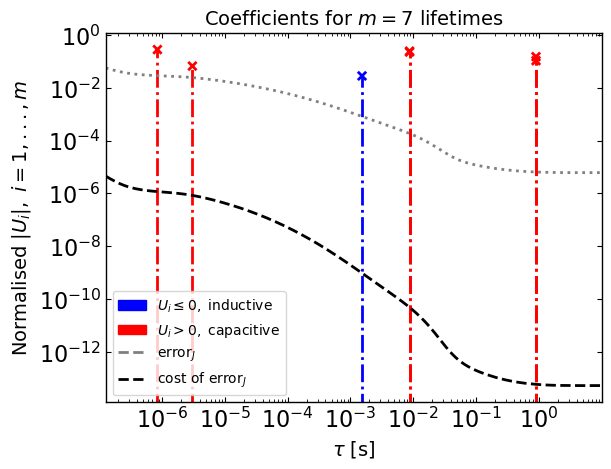

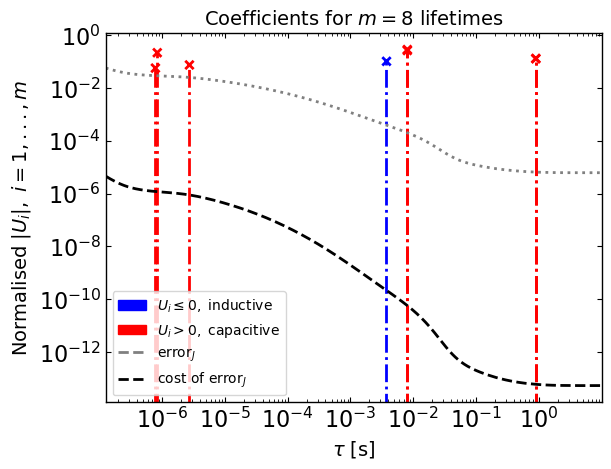

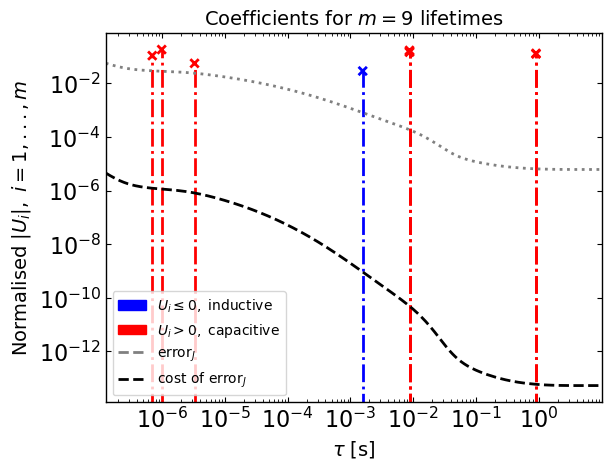

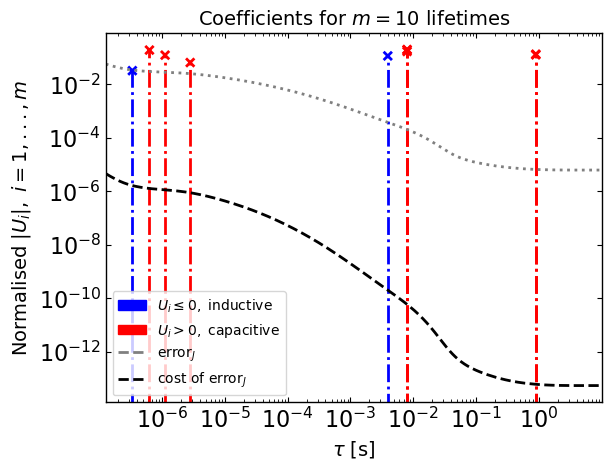

In [72]:
import matplotlib.patches as patches
import matplotlib.lines as mlines
# Plot |U| against t for each m 
xlim = [time[0], time[-1]]
blue_patch = patches.Patch(color='blue', label='$U_i \\leq 0,$ inductive')
red_patch = patches.Patch(color='red', label='$U_i > 0, $ capacitive')
black_line = mlines.Line2D([], [], color='black', linestyle='--', label='$\\text{cost of error}_J$')
grey_line = mlines.Line2D([], [], color='grey', linestyle='--', label='$\\text{error}_J$')

# blue_line = mlines.Line2D([], [], color='blue', linestyle='-.', marker='x', markersize=8, label='$U_i \\leq 0$')
# red_line = mlines.Line2D([], [], color='red', linestyle='-.', marker='x', markersize=8, label='$U_i > 0$')

for fit in fits:
    polarity = fit.U > 0
    colour_map = list(map(str, np.where(polarity, 'r', 'b')))
    marker_map = list(map(str, np.where(polarity, 'x', 'v')))
    plt.vlines(fit.tau, ymin=0, ymax=np.abs(fit.U), colors=colour_map, linestyles='-.')
    plt.scatter(fit.tau, np.abs(fit.U), c=colour_map, marker='x')
    
    plt.plot(time, scaled_current_cost, color='black', linestyle='--')
    plt.plot(time, scaled_current_error, label='$\sigma_J$', color='grey', linestyle=':')
    plt.xlim(xlim)
    plt.xlabel("$\\tau$ [s]")
    plt.ylabel(f"Normalised $|U_i|,$ $i = 1, ..., m$")
    plt.xscale("log")
    plt.yscale("log")
    plt.title(f"Coefficients for $m=${fit.m} lifetimes")
    plt.legend(handles =[blue_patch, red_patch, grey_line, black_line], prop={'size': 10})
    plt.show()

## Linear Fit

In [96]:
# Define linear fit
def linear_fit_DRT(t, J, tau, bounds=(-np.inf, np.inf)):
    # Make sure array-like objects are numpy arrays
    t = np.array(t)
    J = np.array(J)
    tau = np.array(tau)

    # Get the polarity of the exponentials 
    polarity = 1 if J[-1] < J[0] else -1

    # Create initial guess for U 
    m = len(tau)
    U0 = polarity*np.ones(m)/m
    offset0 = J.max() if polarity == 1 else J.min()

    # Create an initial array-like guess of variables
    x0 = np.concatenate((U0, np.array([offset0])))

    # Assume an array of dimension M + M + 1, where the first M values 
    # correspond to U values, the second group of M values to the tau values 
    # and the final value to the offset
    error = lambda x : ((x[:-1] @ np.exp(-np.outer(1/tau, t))) + x[-1]) - J

    fit = so.least_squares(error, x0=x0, bounds=bounds)

    # Assume params is of dimension 2 x m, where m is the number of tau/U_values
    return fit

In [48]:
# Fit curve
m=966
tau = np.geomspace(time[0], time[-1], m)

linear_fit = linear_fit_DRT(time, scaled_current, tau)
lf_U = linear_fit.x[:m]
lf_offset = linear_fit.x[-1]

[]

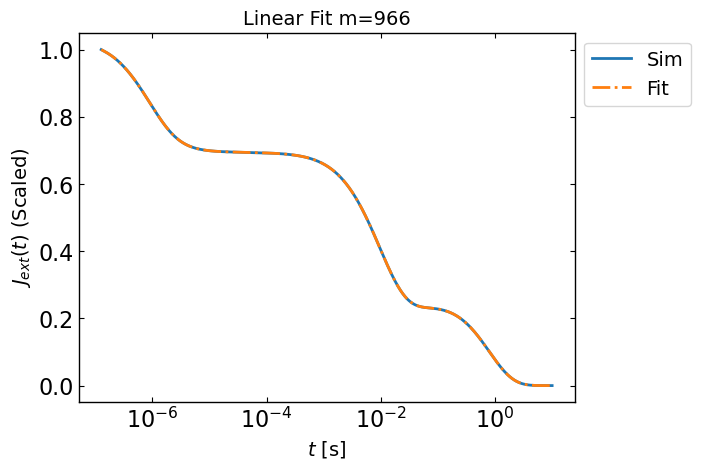

In [49]:
plt.plot(time, scaled_current, label='Sim')
plt.plot(time, drt.DRT_curve(time, lf_U, tau, lf_offset), label=f'Fit', linestyle='-.')
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$ (Scaled)')
plt.title(f"Linear Fit m={m}")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.plot()

Text(0.5, 1.0, 'Coefficients of DRT Linear Fit')

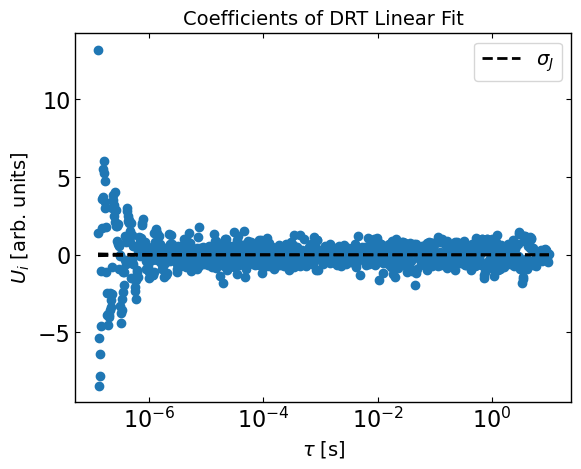

In [50]:
plt.scatter(tau, lf_U)
plt.plot(time, scaled_current_error, linestyle='--', color='black', label="$\\sigma_J$")
plt.plot(time, -scaled_current_error, linestyle='--', color='black')
plt.xscale('log')
plt.ylabel("$U_i$ [arb. units]")
plt.xlabel("$\\tau$ [s]")
plt.legend()
plt.title("Coefficients of DRT Linear Fit")

In [51]:
# Find the linear fit with constraints
linear_fit_constrained = linear_fit_DRT(time, scaled_current, tau, bounds=(0, np.inf))
lf_U_constrained = linear_fit_constrained.x[:m]
lf_offset_constrained = linear_fit_constrained.x[-1]

In [ ]:
# # Save the fitted data 
# with open("threePeakLinearFitScaledConstrainedm966.dat", 'w') as file:
#     file.write('tau U offset_const cost_const'+'\n')
#     for i in range(len(tau)):
#         file.write(f'{tau[i]:.6e} {lf_U_constrained[i]:.6e} {lf_offset_constrained:.6e} {linear_fit_constrained.cost:.6e}' + '\n')

In [61]:
print(linear_fit_constrained.cost)

0.006498925865031119


[]

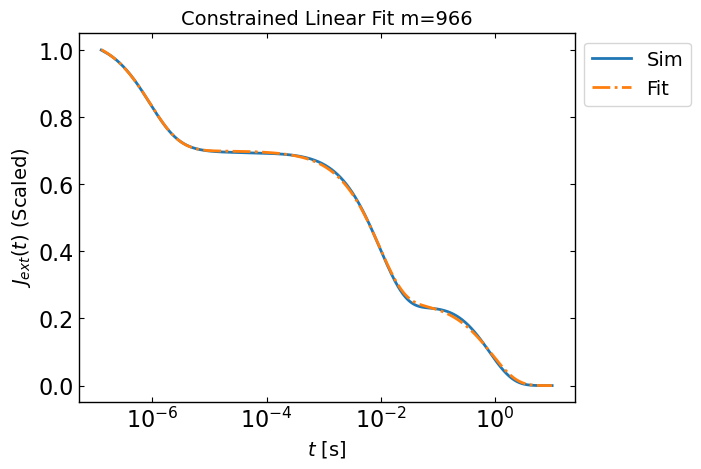

In [52]:
plt.plot(time, scaled_current, label='Sim')
plt.plot(time, drt.DRT_curve(time, lf_U_constrained, tau, lf_offset_constrained), label=f'Fit', linestyle='-.')
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$ (Scaled)')
plt.title(f"Constrained Linear Fit m={m}")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.plot()

Text(0.5, 1.0, 'Coefficients of DRT Linear Fit')

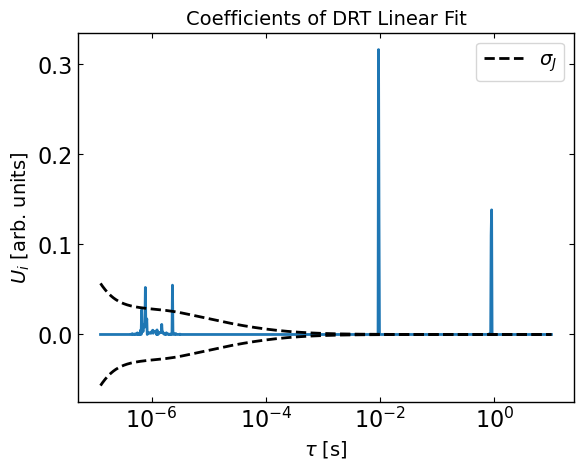

In [53]:
plt.plot(tau, lf_U_constrained)
plt.plot(time, scaled_current_error, linestyle='--', color='black', label="$\\sigma_J$")
plt.plot(time, -scaled_current_error, linestyle='--', color='black')
plt.xscale('log')
plt.ylabel("$U_i$ [arb. units]")
plt.xlabel("$\\tau$ [s]")
plt.legend()
plt.title("Coefficients of DRT Linear Fit")

## Using pytorch to accelerate the non-linear fit

In [92]:
import torch

class DRT_Fit_Result:
    """ A class that bundles together all results from fitting a DRT_curve curve to data

    Attributes
    ----------
    U : numpy.ndarray, shape (m,)
        Fitted coefficients [U_1, U_2, ..., U_m]
    tau : numpy.ndarray, shape (m,)
        Fitted lifetimes [tau_1, tau_2, ..., tau_m]
    offset : numpy.float64
        Fitted value for offset
    cost : numpy.float64
        The value of the cost function 
            F(x) = 0.5 * sum(rho(error_i(x)**2), i = 0, ..., n - 1)
        at the solution. By default, rho(z) = z. See scipy.optimize.least_squares for details
    m : int
        Number of lifetimes/coefficients used in DRT_curve, given by the length of U/tau
    
    Methods
    -------
    set_DRT_curve(t)
        Calculates DRT_curve(t) using the object's attributes (self.U, self.tau, self.offset)
        and sets self.DRT_curve equal to the result 
    """
    def __init__(self, U, tau, offset, cost, m):
        self.U = U
        self.tau = tau 
        self.offset = offset 
        self.cost = cost
        self.m = m 
        self.DRT_curve = None

    def set_DRT_curve(self, t):
        """ Sets self.DRT_curve = DRT_curve(t) using the objects attributes

        Parameters
        ----------
        t : float or list/numpy.ndarray, shape (n,)
            Time values to calculate the DRT_curve curve
        
        Returns
        -------
        None
        """
        self.DRT_curve = DRT_curve_acc(t, self.U, self.tau, self.offset)


######### Function Definitions ####################################################################

def DRT_curve_acc(t, U, tau, offset=0, acc=False):
    """Calculate the function 
        DRT_curve(t) = U_1*exp(-t/tau_1) + U_2*exp(-t/tau_2) + ... + U_m*exp(-t/tau_m) + offset
    
    Parameters
    ----------
    t : float or list/numpy.ndarray, shape (n,)
        The time values over which the simulated impedance-adjacent experiment takes place
    U : list/numpy.ndarray with shape (m,)
        Coefficients for the exponential decay functions such that U[i] is the coefficient of 
        exp(-t/tau[i])
    tau : list/numpy.ndarray with shape (m,)
        The distribution of relaxation times
    offset : float (optional)
        Offest applied to the sum over exponential decay functions
        
    Returns 
    -------
    calculated_DRT_curve : numpy.ndarray with shape (n,)
        DRT_curve at all time values in t
    """
    # Set the accelerator equal to available device if acc-True, else set it equal to the CPU
    device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() and acc == True else torch.device('cpu')
    
    # Check to make sure all input has been formatted as numpy arrays
    U = torch.tensor(U, device=device)
    tau = torch.tensor(tau, device=device)
    
    if not isinstance(t, list) and not isinstance(t, np.ndarray):
        t = torch.tensor([t], device=device)
    elif not isinstance(t, torch.Tensor):
        t = torch.tensor(t, device=device)
    
    # Calculate DRT_curve(t) for all values in t
    calculated_DRT_curve = (U @ torch.exp(-torch.outer(1/tau, t))) + offset
    
    return calculated_DRT_curve


def fit_DRT_curve_acc(t, y, U0, tau0, offset0=0, set_DRT_curve=True, acc=False, **kwargs):
    """Fits an DRT_curve(t) curve to a function y(t)

    Uses a non-linear approach to fit 
        DRT_curve(t) = U_1*exp(-t/tau_1) + U_2*exp(-t/tau_2) + ... + U_m*exp(-t/tau_m) + offset
    to a function y by finding the optimal values for the parameters 
        U = [U_1, U_2, ..., U_m] 
        tau = [tau_1, tau_2, ..., tau_m]
        
    Parameters
    ----------
    t : (list/numpy.ndarray) with shape (n,)
        The time values over which the function y is known
    y : list/numpy.ndarray with shape (n,)
        The values of y(t) that DRT_curve will be fitted to
    U0 : list/numpy.ndarray with shape (m,)
        Initial guess of U values for fitting 
    tau0 : list/numpy.ndarray with shape (m,)
        Initial guess of tau values for fitting
    offset0 : float (optional)
        Initial guess of the DRT_curve offset value
    set_DRT_curve : bool (optional)
        If true, will set the DRT_curve attribute of the returned DRT_Fit_Result object using t
    kwargs
        Keyword arguments passed to scipy.optimize.least_squares for fitting
    
    Returns
    -------
    drt_fit : DRT_Fit_Result 
        With attributes as follows
            U : numpy.ndarray, shape (m,)
                Fitted [U_1, U_2, ..., U_m] array
            tau : numpy.ndarray, shape (m, )
                Fitted [tau_1, tau_2, ..., tau_m] array
            offset : numpy.float64
                Fitted value for offset
            cost : numpy.float64
                The value of the cost function 
                    F(x) = 0.5 * sum(rho(error_i(x)**2), i = 0, ..., n - 1)
                at the solution. By default, rho(z) = z. See scipy.optimize.least_squares for details
            m : int
                Number of lifetimes/coefficients used in DRT_curve, given by the length of U/tau
    """
    
    # Make sure passed parameters are numpy.ndarrays
    t = np.array(t)
    y = np.array(y)
    U0 = np.array(U0)
    tau0 = np.array(tau0)
    m = len(U0)
    
    # Create an initial parameter array to pass to the fitting algorithm
    initial_params = np.concatenate((U0, tau0, [offset0]))
    
    # Create the error function 
    error = lambda x : y - DRT_curve_acc(t, x[:m], x[m:-1], offset=x[-1], acc=acc)
    
    # Fit the params using scipy. Note x_scale='jac' makes for better fits than the default value
    fit = so.least_squares(error, x0=initial_params, x_scale='jac', **kwargs)
    
    # Store the fit results
    drt_fit = DRT_Fit_Result(fit.x[:m], fit.x[m:-1], fit.x[-1], fit.cost, m)

    # Set the DRT_curve curves for each DRT_Fit_Result result if calc_DRT_curve=True
    drt_fit.set_DRT_curve(t) if set_DRT_curve else None
    
    return drt_fit


def linear_fit_DRT_acc(t, y, tau, bounds=(-np.inf, np.inf), acc=False):
    # Make sure array-like objects are numpy arrays
    t = np.array(t)
    y = np.array(y)
    tau = np.array(tau)

    # Get the polarity of the exponentials 
    polarity = 1 if y[-1] < y[0] else -1

    # Create initial guess for U 
    m = len(tau)
    U0 = polarity*np.ones(m)/m
    offset0 = y.max() if polarity == 1 else y.min()

    # Create an initial array-like guess of variables
    x0 = np.concatenate((U0, np.array([offset0])))

    # Assume an array of dimension M + M + 1, where the first M values 
    # correspond to U values, the second group of M values to the tau values 
    # and the final value to the offset
    # error = lambda x : ((x[:-1] @ np.exp(-np.outer(1/tau, t))) + x[-1]) - y

    # Create the error function 
    error = lambda x : y - DRT_curve_acc(t, x[:-1], tau, offset=x[-1], acc=acc).cpu().numpy()

    fit = so.least_squares(error, x0=x0, bounds=bounds)

    # Assume params is of dimension 2 x m, where m is the number of tau/U_values
    return fit


def multi_fit_DRT_curve(t, y, m_values, U_scale_factor=0, offset0=0, set_DRT_curve=True, **kwargs):
    """ Runs fit_DRT_curve over multiple m values 
    
    Parameters
    ----------
    t : list or numpy.ndarray, shape (n,)
        Time values over which y(t) is known
    y : list or numpy.ndarray, shape(n, )
        y(t) values each DRT_curve curve is fitted to
    m_values : list, shape (i,)
        Various m values for fit_DRT_curve, where m is the number of coefficients/lifetimes
        in DRT_curve(t)
    U_scale_factor : {'Auto', float, function(m_values) -> list or numpy.ndarray, shape (m,)}, optional
        Controls intial guess of the coefficients U0 passed to fit_DRT_curve. float will set 
        U0 = [float, float, ..., float] with shape (m,) for each m in m_values. function(m)
        allows the user to pass a function which takes m as an argument and sets U0, the 
        initial coefficient guess, equal to the function's output.
    offset0 : float 
        Initial guess for the offset passed to fit_DRT_curve
    set_DRT_curve : bool (optional)
        If true, will set the DRT_curve attribute of the returned DRT_Fit_Result objects using t
    kwargs 
        Keyword arguments passed to scipy.optimize.least_squares for fitting

    Returns
    -------
    fits : list of DRT_Fit_Result, shape (i,)
        List of DRT_Fit_Result objects, one for each passed m value
    """
    fits = []
    
    # Fit the params for each m
    for m in m_values:
        # Default estimate U, tau, and offset 
        U0 = np.ones(m)*U_scale_factor
        tau0 = np.geomspace(t[0], t[-1], m)
        offset0 = offset0
        
        # Fit the curve
        fit = fit_DRT_curve_acc(t, y, U0, tau0, offset0=offset0, set_DRT_curve=set_DRT_curve, **kwargs)
        
        # Add to fits
        fits.append(fit)
        
    return fits

In [100]:
m_acc = 400
tau_acc = np.geomspace(time[0], time[-1], m_acc)
linear_fit_constrained_acc = linear_fit_DRT_acc(time, scaled_current, tau_acc, bounds=(0, np.inf), acc=False)

In [99]:
m_acc = 400
tau_acc = np.geomspace(time[0], time[-1], m_acc)
linear_fit_constrained_acc = linear_fit_DRT(time, scaled_current, tau_acc, bounds=(0, np.inf))

In [101]:
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device('cpu')

In [103]:
torch.accelerator.is_available()

False

It seems that even though there is no hardware accelerator available, the algorithms that use tensor.Tensor objects instead of numpy.ndarray are just as fast, if not faster

[]

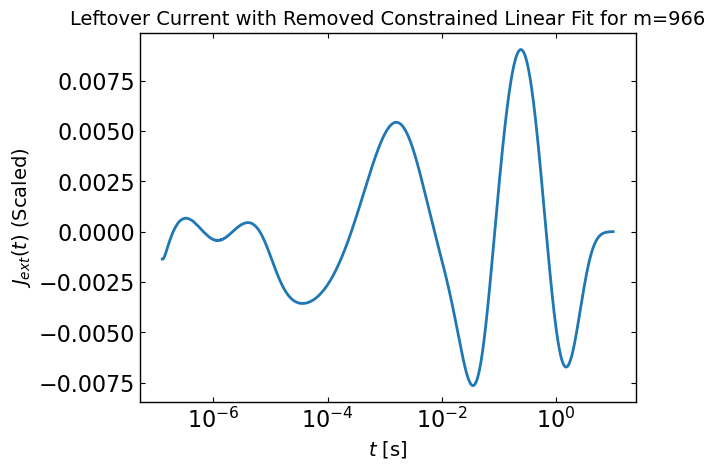

In [106]:
plt.plot(time, scaled_current - drt.DRT_curve(time, lf_U_constrained, tau, lf_offset_constrained))
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$ (Scaled)')
plt.title(f"Leftover Current with Removed Constrained Linear Fit for m={m}")
plt.plot()

In [107]:
## Fit linear with inverted constraints
tau = np.geomspace(time[0], time[-1], m)
linear_fit_constrained_inverted = linear_fit_DRT_acc(time, scaled_current, tau, bounds=(-np.inf, 0))
lf_U_constrained = linear_fit_constrained_inverted.x[:m]
lf_offset_constrained = linear_fit_constrained_inverted.x[-1]

ValueError: Initial guess is outside of provided bounds